# **PREPROCESSING**

Load the necessary libraries.

In [ ]:
import os
import pandas as pd
import soundfile as sf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
import yaml
import matplotlib.pyplot as plt

Load parameters and other configuration values.

In [ ]:
# Load audio preprocessing constants from config.yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

SAMPLING_RATE = config["audio_processing"]["sampling_rate"] # Resample the audio files with frequency 4 kHz, since wheezes and crackles are typically within frequency range 0–2 kHz
FRAME_LENGTH = config["audio_processing"]["frame_length"] # Use window size of 0.3 s for each cycle
HOP_LENGTH = config["audio_processing"]["hop_length"] # Use 50% overlap
N_MFCC = config["audio_processing"]["n_mfcc"] # Extract the first 13 MFCCs
N_MELS = config["audio_processing"]["n_mels"] # Use 20 Mel Filterbanks to extract the Log-Mel Spectrograms
F_HI = config["audio_processing"]["f_hi"] # Boundary frequency for VLTP is set to 2 kHz
TARGET_DURATION = config["audio_processing"]["target_duration"] # Fix the duration of each cycle to 3 s

FRAME_SIZE = int(FRAME_LENGTH * SAMPLING_RATE) # Calculate the amount of samples per frame
HOP_SIZE = int(HOP_LENGTH * SAMPLING_RATE) #  Calculate the amount of samples per hop

# Load basic paths from config.yaml
DATA_FOLDER = os.path.join(os.getcwd(), config["paths"]["data_folder"])
AUDIO_FOLDER = os.path.join(os.getcwd(), config["paths"]["audio_folder"])
OUTPUT_FOLDER = os.path.join(os.getcwd(), config["paths"]["output_folder"])
RAW_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder"])
RAW_CYCLE_FOLDER_ORIGINAL = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder_original"])
AUG_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["aug_cycle_folder"])
FILTERED_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["filtered_cycle_folder"])
CLEANED_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["cleaned_cycle_folder"])
TRAINING_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["training_set_folder"])
TEST_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["test_set_folder"])

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(RAW_CYCLE_FOLDER, exist_ok=True)
os.makedirs(RAW_CYCLE_FOLDER_ORIGINAL, exist_ok=True)
os.makedirs(AUG_CYCLE_FOLDER, exist_ok=True)
os.makedirs(FILTERED_CYCLE_FOLDER, exist_ok=True)
os.makedirs(CLEANED_CYCLE_FOLDER, exist_ok=True)
os.makedirs(TRAINING_SET_FOLDER, exist_ok=True)
os.makedirs(TEST_SET_FOLDER, exist_ok=True)

We plot for example the first 5 .wav files of the RSDB dataset and visualize the class of every respiratory cycle they contain for better understanding. First of all we **resample** all the recordings with **SAMPLING RATE = 4 kHz**. 

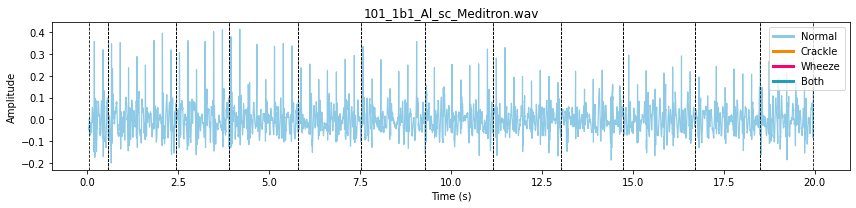

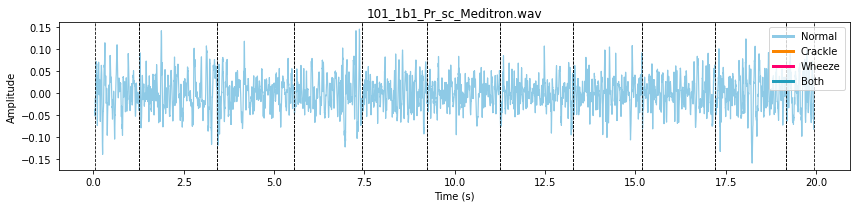

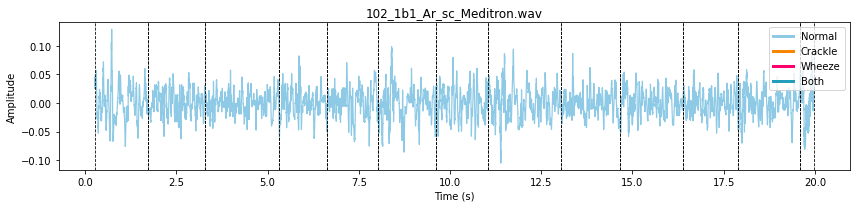

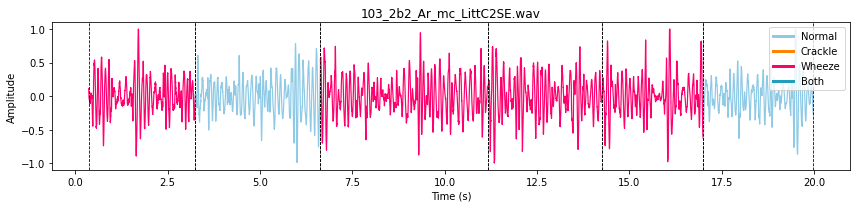

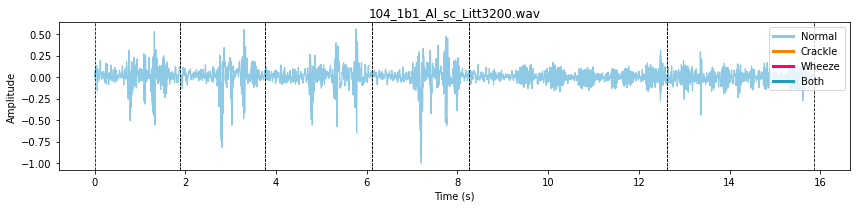

In [11]:
from utils.visuals import plot_dataset_waveforms

plot_dataset_waveforms(AUDIO_FOLDER, k=5, sr=SAMPLING_RATE)

We also plot the 5 first spectrograms that correspond to these waveforms. For the STFT we will use **frames of duration 60 ms** and **50% overlap** between them. Also, a **Hann window** is applied in order to omit spectral leakage.

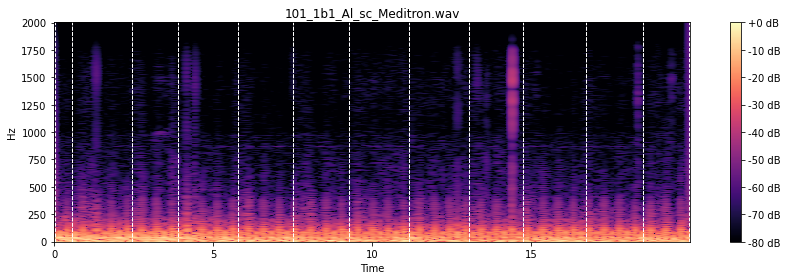

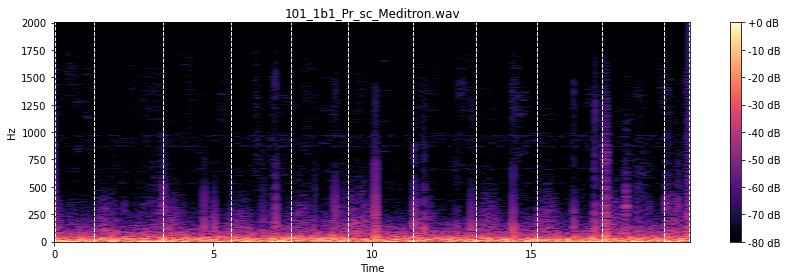

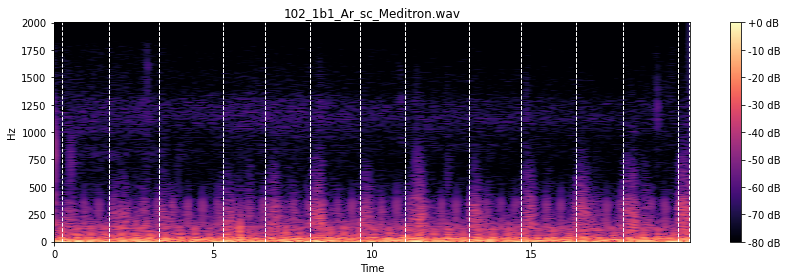

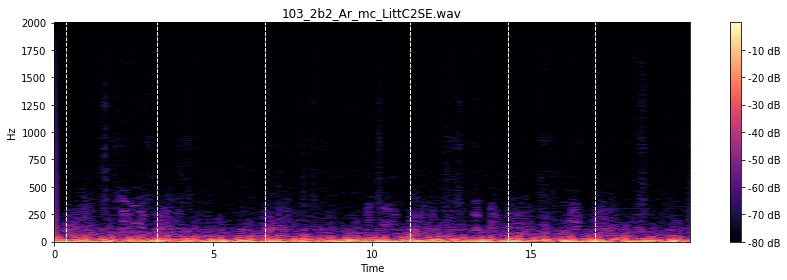

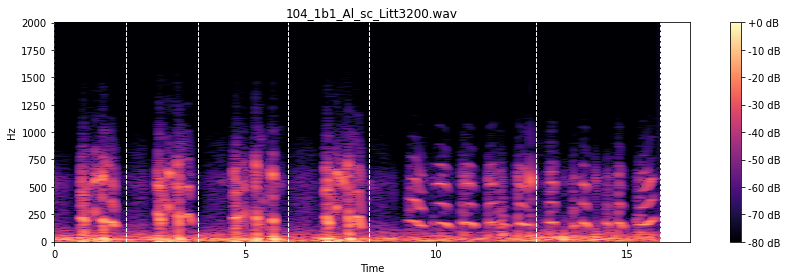

In [ ]:
from utils.plots import plot_dataset_spectrograms

plot_dataset_spectrograms(
    audio_folder=AUDIO_FOLDER,
    k=5,
    sr=SAMPLING_RATE,
    hop_length=HOP_SIZE
)

Then, we **split all .wav files into respiratory cycles** using the annotation files and normalize each cycle into a fixed length. In order to detect the most suitable target length, we plot the distribution of the respiratory cycles durations. We can see that the majority of the respiratory cycles have duration close to **2 s**, so the chosen fixed duration is set to **3 s**. We fix the length of each respiratory cycle by applying **circular padding or trimming**. After this we split the fixed respiratory cycles into **training and testing sets** while preserving the initial ratio of the instances of each class. 

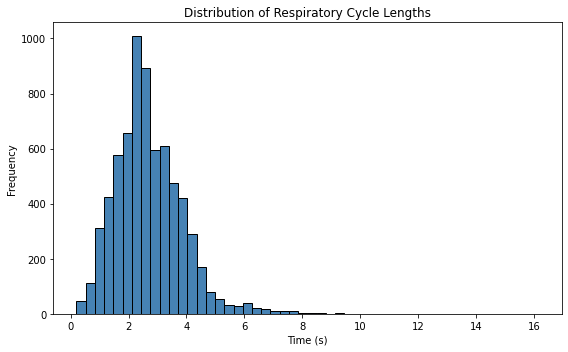

In [50]:
from utils.visuals import plot_cycle_duration_distribution

plot_cycle_duration_distribution(AUDIO_FOLDER)

In [13]:
from utils.audio_preprocessing import fix_cycle_length, classify

# Steps 1 & 2: Resample and segment raw audio files into respiratory cycles with fixed length using annotation files
raw_rows = []
for file in os.listdir(AUDIO_FOLDER):
    if file.endswith(".wav"):
        name = file.replace(".wav", "")
        txt_path = os.path.join(AUDIO_FOLDER, name + ".txt")
        if not os.path.exists(txt_path):
            continue

        y, sr = librosa.load(os.path.join(AUDIO_FOLDER, file), sr=SAMPLING_RATE)
        annotations = np.loadtxt(txt_path)

        for i, (start, end, crackle, wheeze) in enumerate(annotations):
            y_seg_orig = y[int(start * sr): int(end * sr)]
            if len(y_seg_orig) < 2 or np.isnan(y_seg_orig).any():
                print(f"Skipping invalid segment: {name}_cycle{i}")
                continue

            # Save original cycles 
            fname_orig = f"{name}_cycle{i}_original.wav"
            sf.write(os.path.join(RAW_CYCLE_FOLDER_ORIGINAL, fname_orig), y_seg_orig, sr)

            y_seg_fixed = fix_cycle_length(y_seg_orig, sr, target_duration=TARGET_DURATION)
            fname_fixed = f"{name}_cycle{i}.wav"
            sf.write(os.path.join(RAW_CYCLE_FOLDER, fname_fixed), y_seg_fixed, sr)
            
            raw_rows.append([fname_fixed, int(crackle), int(wheeze)])

df = pd.DataFrame(raw_rows, columns=["file", "crackle", "wheeze"])
df["class"] = df.apply(lambda r: classify(r["crackle"], r["wheeze"]), axis=1)

# Remove class 'Both' since we will not use it from now on
df = df[df["class"] != "Both"].reset_index(drop=True)

# Step 3: Split cycles into train/test sets for the classification using stratified split to preserve the class ratio
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["class"], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

We plot some waveforms before and after the duration normalization to visualize its effect.

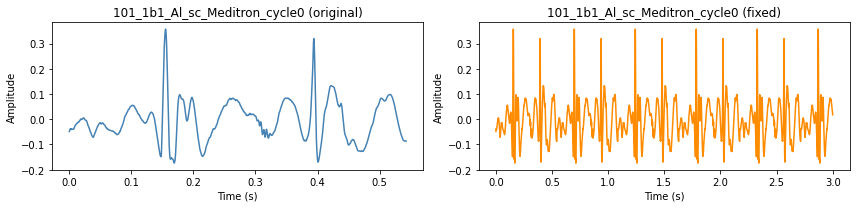

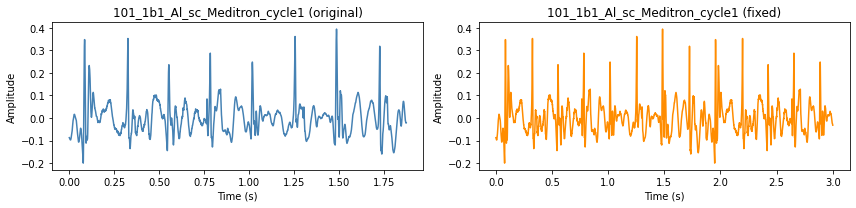

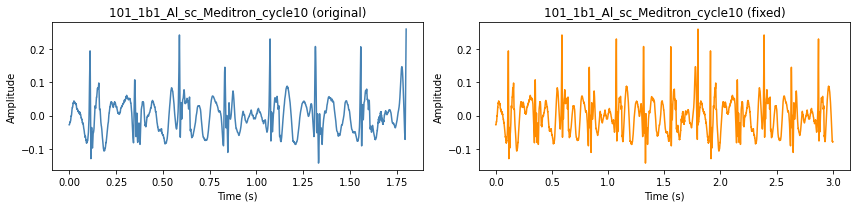

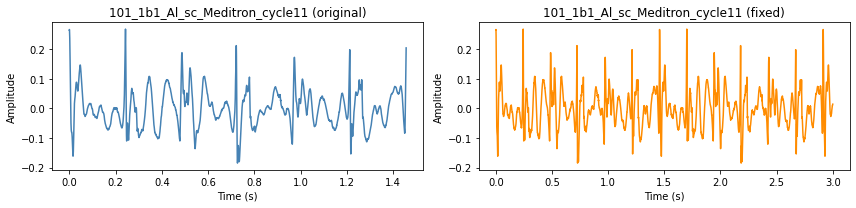

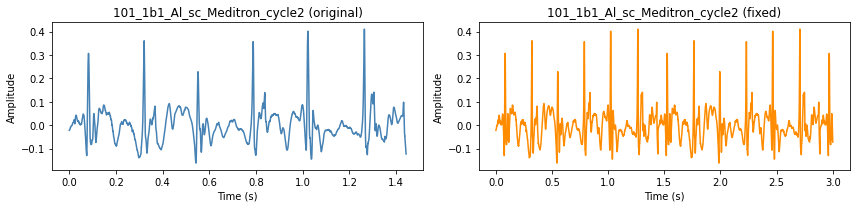

In [ ]:
from utils.plots import plot_respiratory_cycles_after_length_fix

plot_respiratory_cycles_after_length_fix(
    original_folder=RAW_CYCLE_FOLDER_ORIGINAL,
    fixed_folder=RAW_CYCLE_FOLDER,
    k=5,
    sr=SAMPLING_RATE,
)

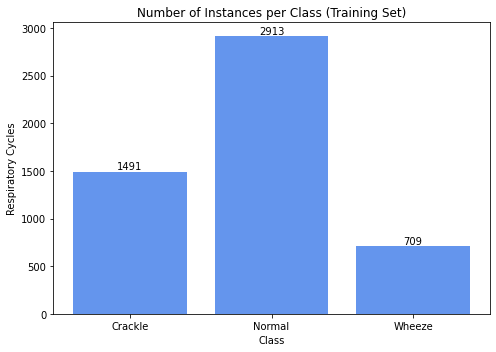

In [ ]:
# Visualize class distribution in training set
label_counts = Counter(train_df["class"])

plt.figure(figsize=(7, 5))
plt.bar(label_counts.keys(), label_counts.values(), color="cornflowerblue")
plt.title("Number of Instances per Class (Training Set)")
plt.xlabel("Class")
plt.ylabel("Respiratory Cycles")

for i, (label, count) in enumerate(label_counts.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

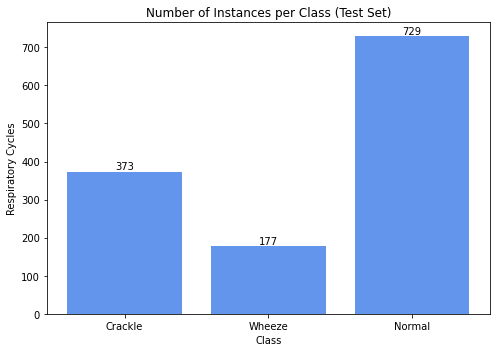

In [ ]:
# Visualize class distribution in test set
label_counts = Counter(test_df["class"])

plt.figure(figsize=(7, 5))
plt.bar(label_counts.keys(), label_counts.values(), color="cornflowerblue")
plt.title("Number of Instances per Class (Test Set)")
plt.xlabel("Class")
plt.ylabel("Respiratory Cycles")

for i, (label, count) in enumerate(label_counts.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The bar chart shows a **clear class imbalance in both training and test set**. Specifically, the **"class 'Normal' dominates** the dataset with significantly more samples compared to the 'Crackle', 'Wheeze' classes. This imbalance may lead to biased model performance, so we handle it by appling **VTLP Data Augmentation** on the training set. The test set on the other hand must remain as it is in order to resemble real life testing data.

In [ ]:
from utils.audio_preprocessing import apply_vtlp

# Set uniform target count based on class 'Normal' which is the majority class
target_count = len(train_df[train_df["class"] == "Normal"])
augmented_labels = []

# Step 4: Apply VTLP-Patch Augmentation only on minority classes 'Crckle', 'Wheeze'
for cls in train_df["class"].unique():
    df_cls = train_df[train_df["class"] == cls]
    current_count = len(df_cls)
    n_needed = target_count - current_count

    n_per_sample = int(np.ceil(n_needed / current_count))

    if cls != 'Normal':
        print(f"Augmenting class {cls} with {n_needed} new samples ({n_per_sample} per original)")

        for idx, (_, row) in tqdm(enumerate(df_cls.iterrows()), total=len(df_cls), desc=f"Augmenting class {cls}"):
            for j in range(n_per_sample):
                if n_needed <= 0:
                    break

                path = os.path.join(RAW_CYCLE_FOLDER, row["file"])
                y, sr = librosa.load(path, sr=SAMPLING_RATE)

                alpha = np.random.uniform(0.8, 1.2) if cls in ["Crackle", "Wheeze"] else np.random.uniform(0.9, 1.1)

                y_aug = apply_vtlp(
                    y, sr,
                    frame_size=FRAME_SIZE,
                    hop_size=HOP_SIZE,
                    n_mels=N_MELS,
                    f_hi=F_HI,
                    alpha=alpha
                )
                y_aug = fix_cycle_length(y_aug, sr, target_duration=TARGET_DURATION)
                fname = f"AUG_{row['file'].replace('.wav', '')}_vtlp{idx}_{j}.wav"
                sf.write(os.path.join(AUG_CYCLE_FOLDER, fname), y_aug, sr)

                augmented_labels.append({
                    "file": fname,
                    "crackle": int(row["crackle"]),
                    "wheeze": int(row["wheeze"]),
                    "class": classify(int(row["crackle"]), int(row["wheeze"]))
                })

                n_needed -= 1

# Save final augmented labels
augmented_labels_df = pd.DataFrame(augmented_labels)

Augmenting class Crackle with 1422 new samples (1 per original)


Augmenting class Crackle: 100%|██████████| 1491/1491 [02:24<00:00, 10.34it/s]


Augmenting class Wheeze with 2204 new samples (4 per original)


Augmenting class Wheeze: 100%|██████████| 709/709 [03:18<00:00,  3.58it/s]


We then plot some of the augmented cycles to check if their spectral behavior is similar. 

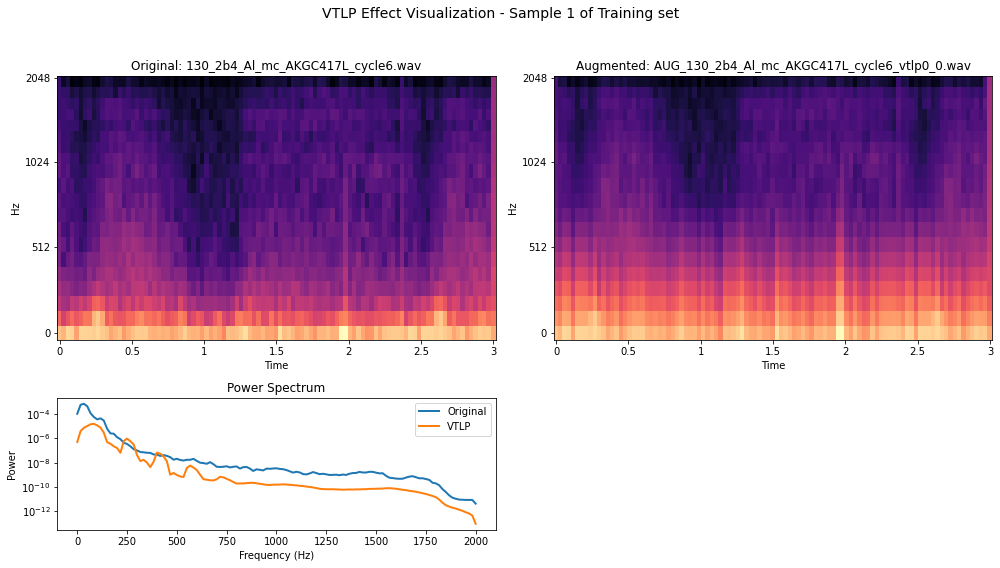

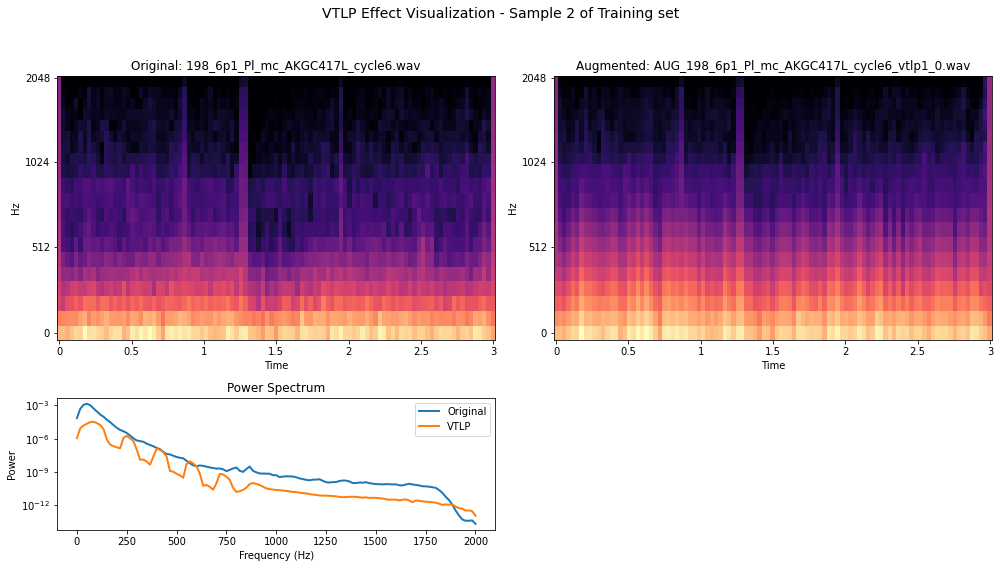

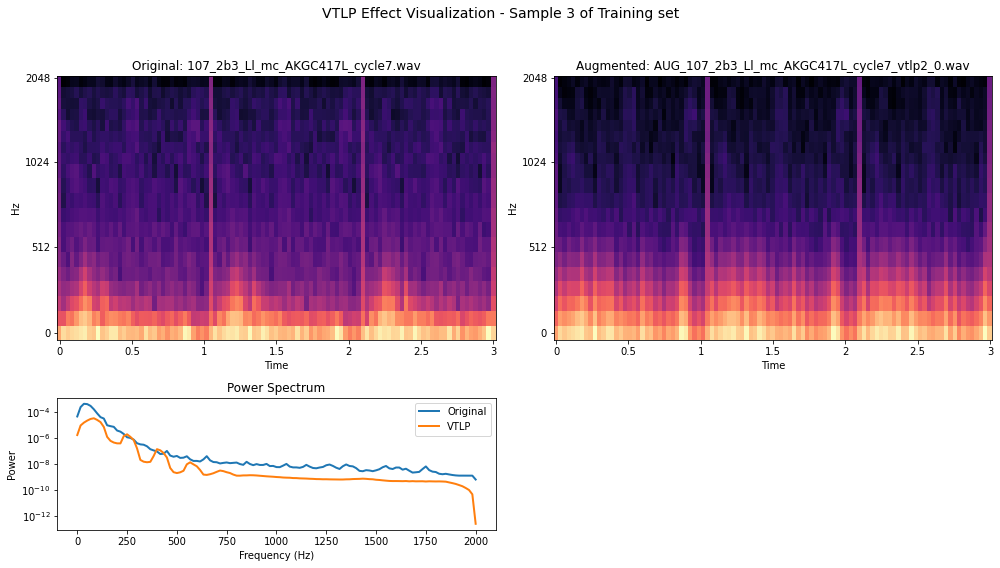

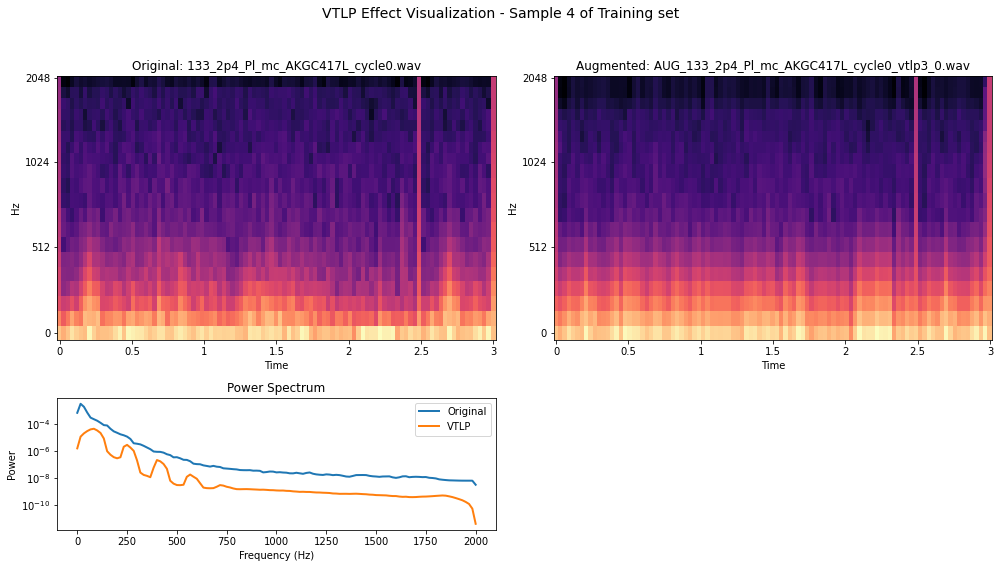

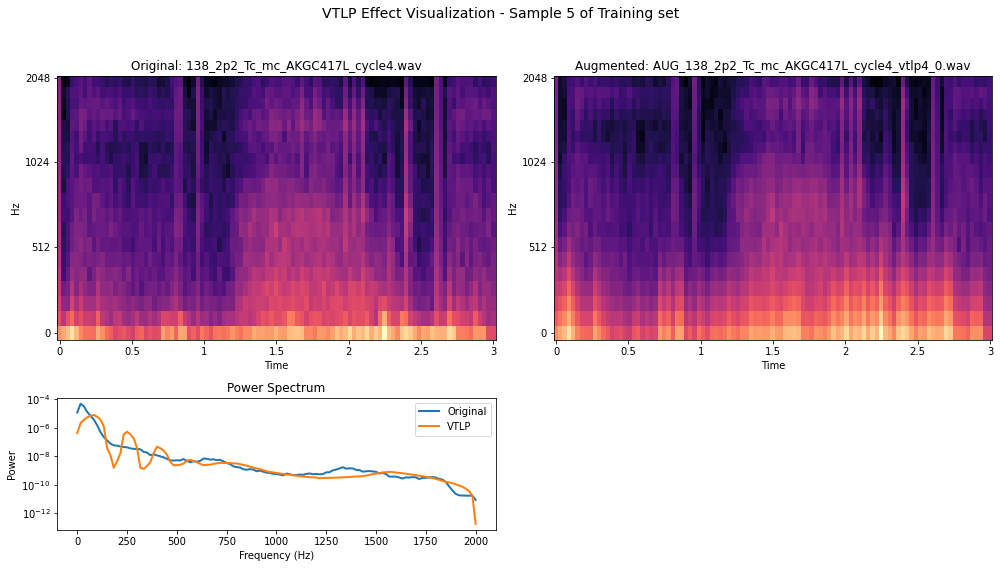

In [10]:
from utils.visuals import plot_vtlp_effects

plot_vtlp_effects(
    augmented_df=augmented_labels_df,
    raw_folder=RAW_CYCLE_FOLDER,
    aug_folder=AUG_CYCLE_FOLDER,
    k=5,
    sr=SAMPLING_RATE,
    n_fft=FRAME_SIZE,
    hop_length=HOP_SIZE,
    n_mels=N_MELS
)

In [11]:
# After the augmentation we check if each label is indeed equally represented
final_train_df = pd.concat([train_df, augmented_labels_df], ignore_index=True) # Combine raw and augmneted cycles for training set
print("\nClass distribution in training set after augmentation:")
for cls, count in final_train_df["class"].value_counts().items():
    print(f"{cls}: {count} instances")

final_df = pd.concat([final_train_df, test_df], ignore_index=True)


Class distribution in training set after augmentation:
Crackle: 2913 instances
Normal: 2913 instances
Wheeze: 2913 instances


Before applying the digital filter we see that the majority of high-power low-frequency components are concentrated below 100 Hz, justifying the use of a high-pass filter with a 100 Hz cutoff to suppress low-frequency noise while preserving relevant respiratory information.

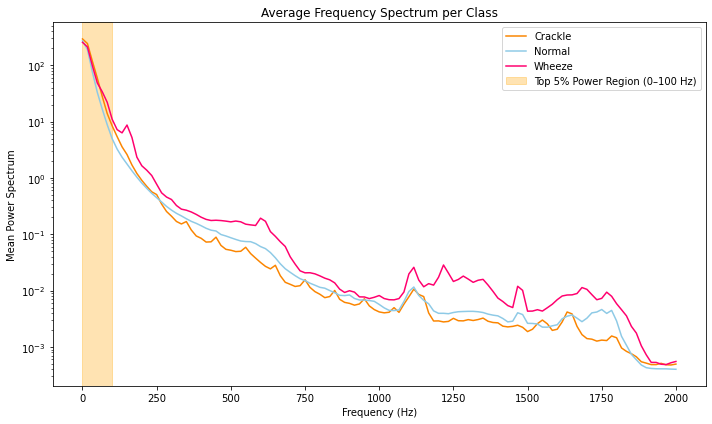

In [12]:
from utils.visuals import plot_average_spectrum_per_class

plot_average_spectrum_per_class(
    train_df=train_df,
    raw_cycle_folder=RAW_CYCLE_FOLDER,
    sampling_rate=SAMPLING_RATE,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE
)

Finally, we apply on every cycle of both training and testing set a **highpass filter with cut-off frequency = 100 Hz** to remove heart sounds and silent environmental noise. Also we **normalize the signal amplitude of each cycle into the interval [-1,1]**.

In [ ]:
from utils.audio_preprocessing import preprocess_audio

# Step 5: Preprocess both sets by applying a highpass filter and then normalizing the amplitudes
for fname in tqdm(final_df["file"], desc="Preprocessing all cycles"):
    in_folder = RAW_CYCLE_FOLDER if not fname.startswith("AUG") else AUG_CYCLE_FOLDER
    y_filtered, y_preprocessed, sr = preprocess_audio(os.path.join(in_folder, fname), sr=SAMPLING_RATE, cutoff=100.0)
    sf.write(os.path.join(FILTERED_CYCLE_FOLDER, fname), y_filtered, sr)
    sf.write(os.path.join(CLEANED_CYCLE_FOLDER, fname), y_preprocessed, sr)

Preprocessing all cycles: 100%|██████████| 10018/10018 [01:12<00:00, 138.34it/s]


We first plot some spectrograms before and after the implementation of the highpass filter.

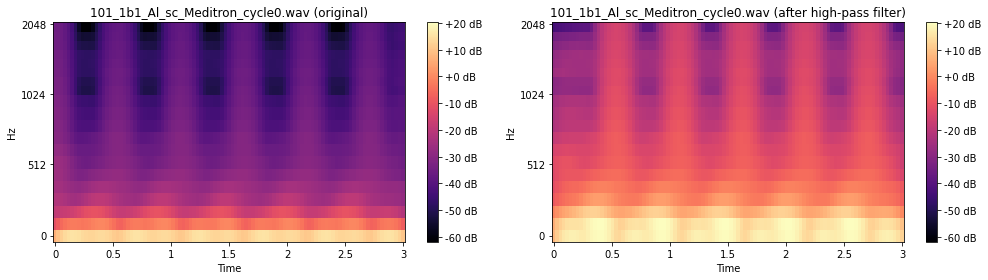

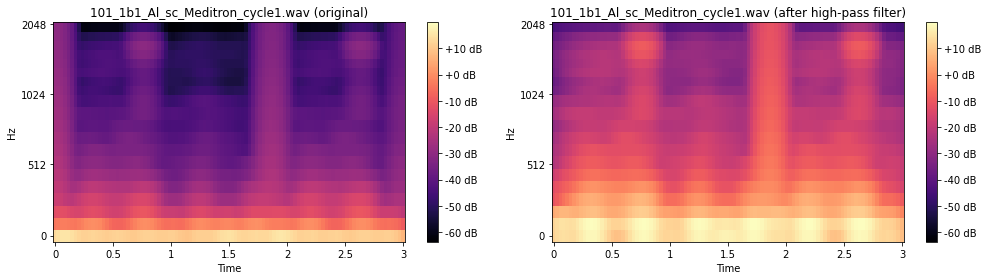

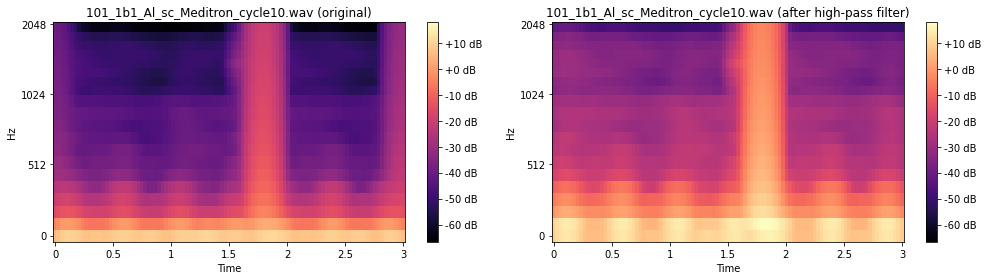

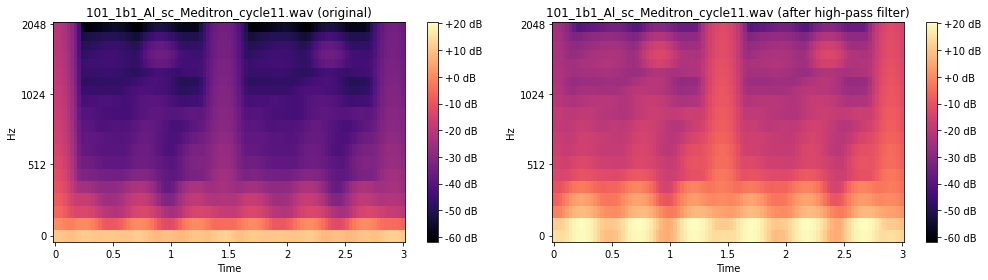

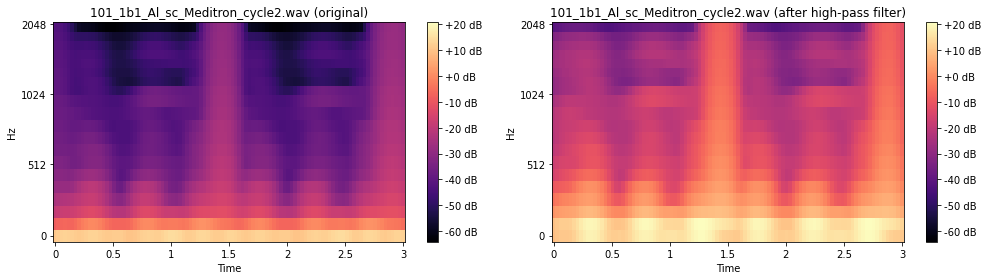

In [ ]:
from utils.plots import plot_spectrograms_after_highpass_filter

plot_spectrograms_after_highpass_filter(
    raw_folder=RAW_CYCLE_FOLDER,
    filtered_folder=CLEANED_CYCLE_FOLDER,
    k=5,
    sr=SAMPLING_RATE,
    n_mels=N_MELS,
    hop_length=HOP_SIZE
)

We also plot some waveforms before and after the amplitude normalization.

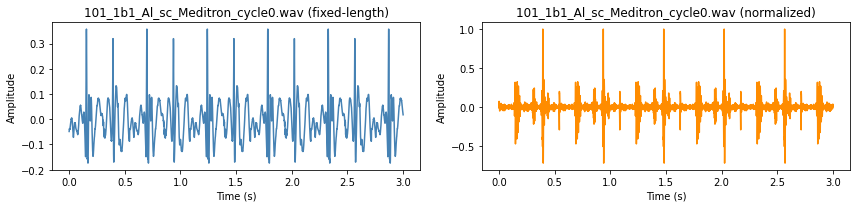

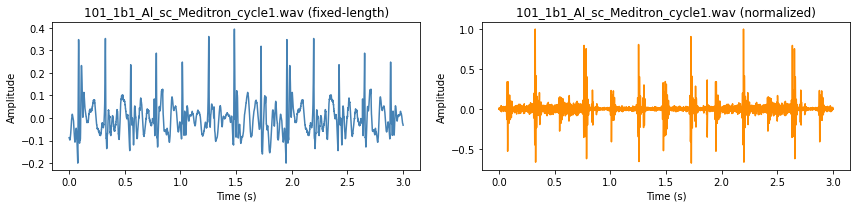

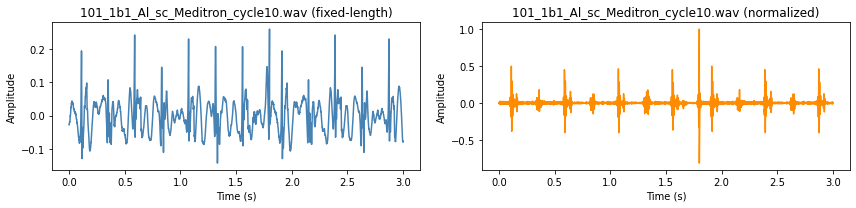

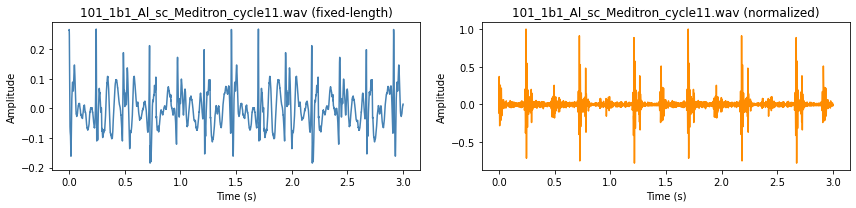

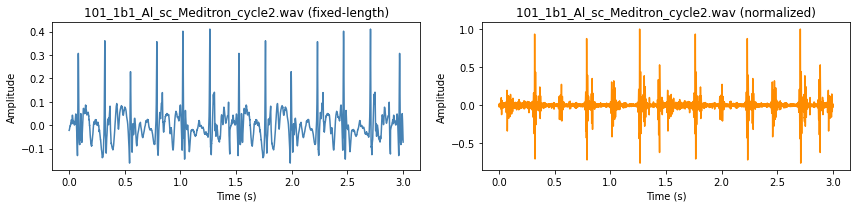

In [ ]:
from utils.plots import plot_respiratory_cycles_after_amplitude_normalization

plot_respiratory_cycles_after_amplitude_normalization(
    raw_folder=RAW_CYCLE_FOLDER,
    cleaned_folder=CLEANED_CYCLE_FOLDER,
    k=5,
    sr=SAMPLING_RATE)

Print the final augmented preprocessed training set.

In [15]:
final_train_df

,file,crackle,wheeze,class
0,130_2b4_Al_mc_AKGC417L_cycle6.wav,1,0,Crackle
1,135_2b1_Al_mc_LittC2SE_cycle3.wav,0,0,Normal
2,151_2p4_Lr_mc_AKGC417L_cycle1.wav,0,1,Wheeze
3,154_1b3_Tc_mc_AKGC417L_cycle4.wav,0,0,Normal
4,198_1b5_Ll_mc_AKGC417L_cycle1.wav,0,1,Wheeze
...,...,...,...,...
8734,AUG_198_1b5_Ll_mc_AKGC417L_cycle5_vtlp549_3.wav,0,1,Wheeze
8735,AUG_106_2b1_Pr_mc_LittC2SE_cycle4_vtlp550_0.wav,0,1,Wheeze
8736,AUG_106_2b1_Pr_mc_LittC2SE_cycle4_vtlp550_1.wav,0,1,Wheeze
8737,AUG_106_2b1_Pr_mc_LittC2SE_cycle4_vtlp550_2.wav,0,1,Wheeze


We visualize some respiratory cycles of the training test after the preprocessing pipeline. The signal waveform is split into the different respiratory cycles and every respiratory cycle is seen as an independent instance for the classification model.

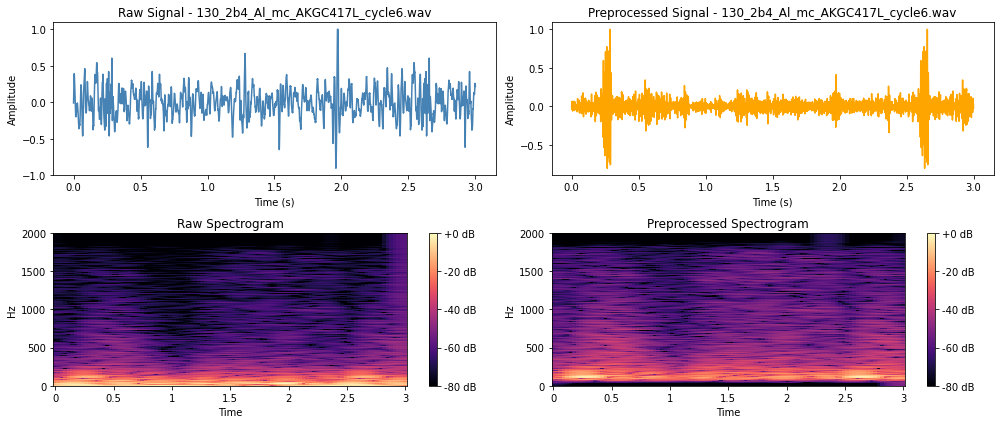

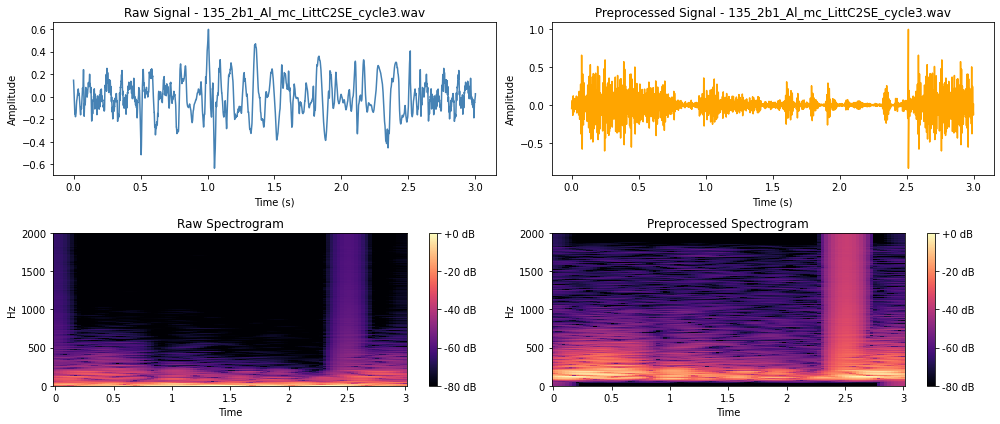

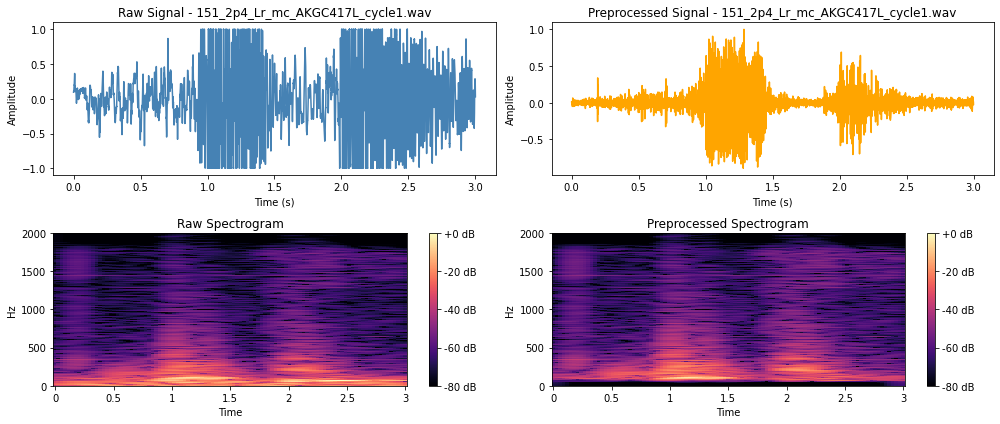

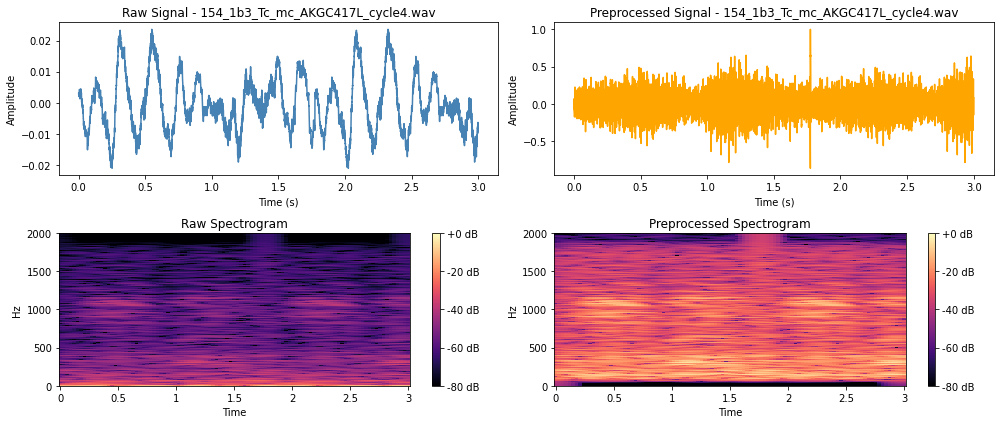

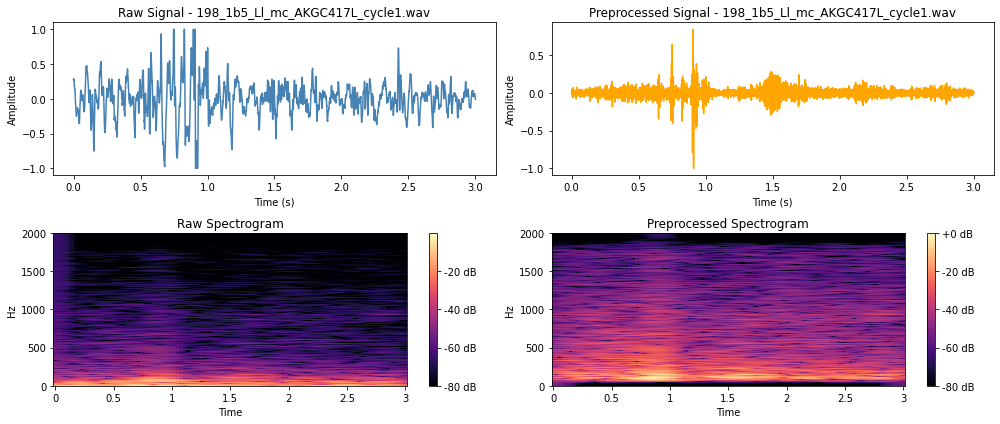

In [36]:
from utils.visuals import plot_signals_after_preprocessing

plot_signals_after_preprocessing(
    train_df=final_train_df,
    corrected_folder=CLEANED_CYCLE_FOLDER,
    raw_folder=RAW_CYCLE_FOLDER,
    sampling_rate=SAMPLING_RATE,
    hop_size=HOP_SIZE,
    k=5
)

The plots show that **the preprocessed signals appear smoother and more regular in amplitude**, indicating suppression of noise and artifacts. The corresponding **spectrograms reveal better-defined frequency structures and reduced background spectral clutter**. This suggests the preprocessing successfully enhanced the clarity and consistency of the breathing cycles while preserving important acoustic information.

Print the final preprocessed test set.

In [16]:
test_df

,file,crackle,wheeze,class
0,145_2b2_Ar_mc_AKGC417L_cycle3.wav,1,0,Crackle
1,192_2b1_Al_mc_LittC2SE_cycle2.wav,0,1,Wheeze
2,195_1b1_Ar_sc_Litt3200_cycle7.wav,0,0,Normal
3,205_1b3_Lr_mc_AKGC417L_cycle2.wav,1,0,Crackle
4,144_1b1_Al_sc_Meditron_cycle8.wav,0,0,Normal
...,...,...,...,...
1274,193_1b2_Ar_mc_AKGC417L_cycle6.wav,0,1,Wheeze
1275,163_8b3_Lr_mc_AKGC417L_cycle1.wav,0,0,Normal
1276,139_1b1_Ar_sc_Litt3200_cycle6.wav,0,0,Normal
1277,208_1b1_Ll_sc_Meditron_cycle11.wav,0,0,Normal


We also visualize some respiratory cycles of the test test after the preprocessing pipeline.

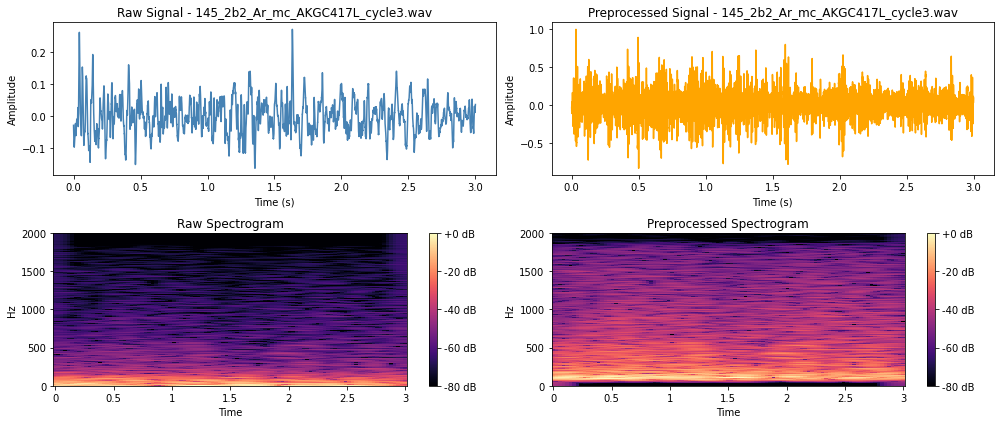

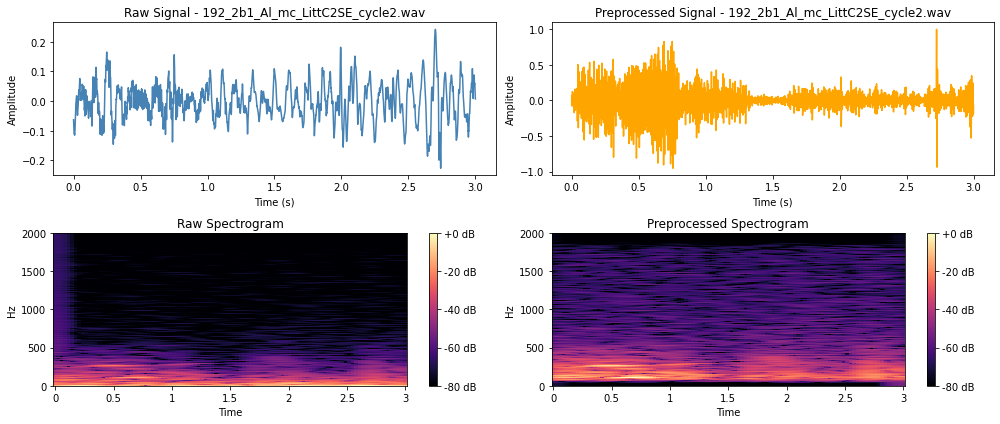

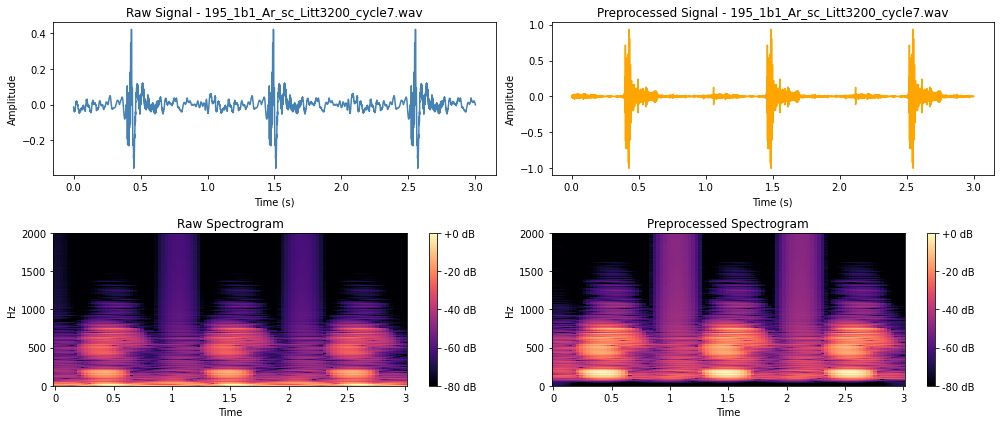

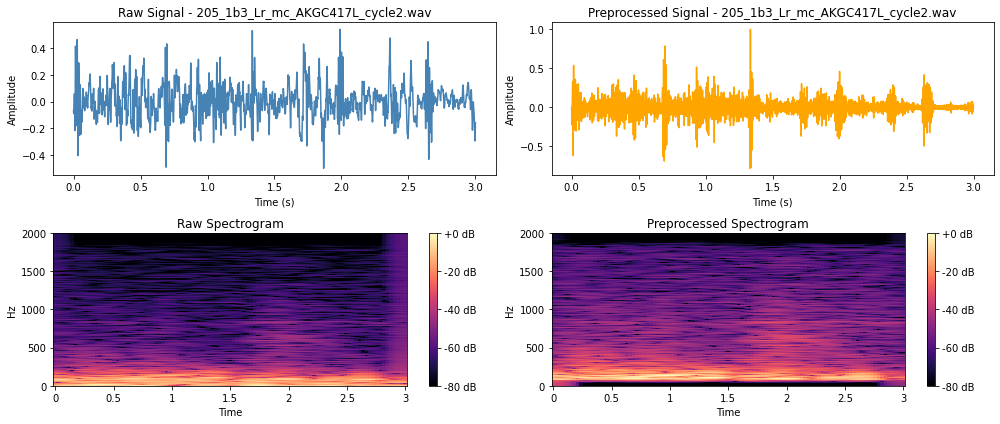

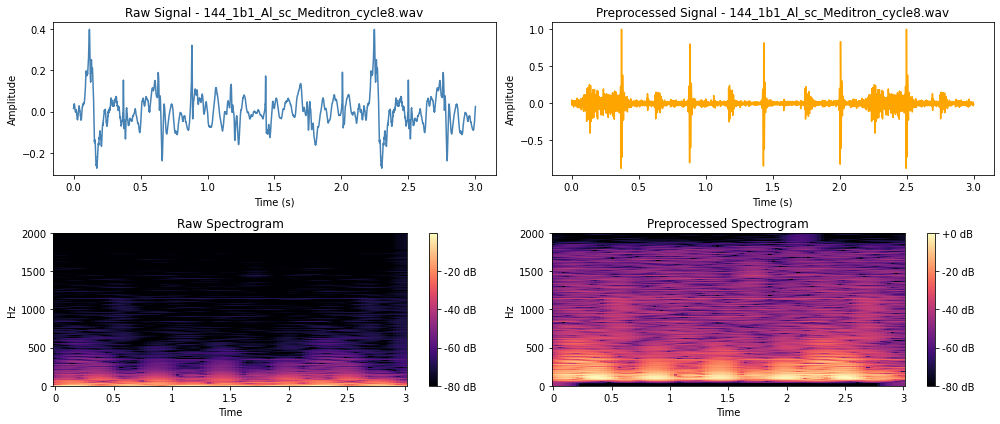

In [37]:
from utils.visuals import plot_signals_after_preprocessing

plot_signals_after_preprocessing(
    train_df=test_df,
    corrected_folder=CLEANED_CYCLE_FOLDER,
    raw_folder=RAW_CYCLE_FOLDER,
    sampling_rate=SAMPLING_RATE,
    hop_size=HOP_SIZE,
    k=5
)

Save tha datasets.

In [17]:
dfs = [
    (augmented_labels_df, "augmented_training_set.csv"),
    (train_df, "raw_training_set.csv"),
    (final_train_df, "training_set.csv"),
    (test_df, "test_set.csv"),
]

# Save augmented and final training set
for df, name in dfs[:3]:
    df.to_csv(os.path.join(TRAINING_SET_FOLDER, name), index=False)

# Save test set
df, name = dfs[3]
df.to_csv(os.path.join(TEST_SET_FOLDER, name), index=False)